<a href="https://colab.research.google.com/github/deepthi25p/GAN-Based-Image-Enhancement/blob/main/GAN_Based_Image_Enhancement.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
!pip install tensorflow matplotlib opencv-python

In [2]:
import tensorflow as tf
from tensorflow.keras import layers
import numpy as np
import matplotlib.pyplot as plt
import cv2

In [3]:
from google.colab import files
uploaded = files.upload()

img = cv2.imread(list(uploaded.keys())[0])
img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
img = cv2.resize(img, (128,128)) / 255.0

# Create low-light version
low_light = img * 0.3

Saving car_img.jpg to car_img.jpg


In [5]:
def build_generator():
    model = tf.keras.Sequential([
        layers.Conv2D(64, (3,3), activation='relu', padding='same', input_shape=(128,128,3)),
        layers.Conv2D(64, (3,3), activation='relu', padding='same'),
        layers.Conv2D(3, (3,3), activation='sigmoid', padding='same')
    ])
    return model

generator = build_generator()

In [6]:
def build_discriminator():
    model = tf.keras.Sequential([
        layers.Conv2D(64, (3,3), strides=2, padding='same', input_shape=(128,128,3)),
        layers.LeakyReLU(),
        layers.Flatten(),
        layers.Dense(1, activation='sigmoid')
    ])
    return model

discriminator = build_discriminator()
discriminator.compile(optimizer='adam', loss='binary_crossentropy')

In [7]:
generator.compile(optimizer='adam', loss='mse')

for epoch in range(50):
    generated = generator.predict(np.expand_dims(low_light, axis=0))
    loss = generator.train_on_batch(np.expand_dims(low_light, axis=0),
                                    np.expand_dims(img, axis=0))

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 375ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 65ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 64ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 65ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 67ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 66ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 77ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 65ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 67ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 64ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 65ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 65ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 64ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 66ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 76ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 64ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 64ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 67ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 65ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 65ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 65ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 68ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 105ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 103ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 104ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 102ms/step
1/1 ━━━

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 64ms/step


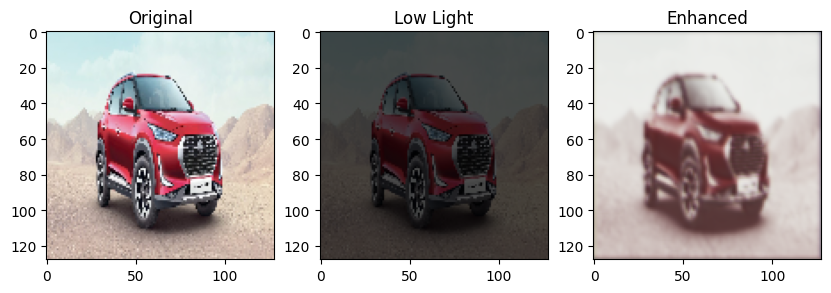

In [8]:
output = generator.predict(np.expand_dims(low_light, axis=0))[0]

plt.figure(figsize=(10,4))

plt.subplot(1,3,1)
plt.title("Original")
plt.imshow(img)

plt.subplot(1,3,2)
plt.title("Low Light")
plt.imshow(low_light)

plt.subplot(1,3,3)
plt.title("Enhanced")
plt.imshow(output)

plt.show()